In [1]:
import copy
import datetime as dt

import astropy.units as u
import dill as pk
import numpy as np
from pathlib import Path

import latcom.utils.map_utils as mu
from astropy.time import Time
from sotodlib import core
from latcom.utils.optical_loading import pwv_interp
from latcom.utils.parsing import parse_dict

%load_ext autoreload
%autoreload 2

In [2]:
with open("../../data/wafer_net_c.pk", "rb") as f:
    wafer_net_c = pk.load(f)

# Plotting

In [3]:
import dill as pk
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pwv = pwv_interp()
with open("../../abscals/results_06262026.pk", "rb") as f:
    result_dict = pk.load(f)

with open("../../nets/nets_07142026.pk", "rb") as f:
    net_dict = pk.load(f)

c_base = (220 / 255, 50 / 255, 32 / 255)
c_goal = (0 / 255, 90 / 255, 181 / 255)

In [4]:
df = parse_dict(net_dict)

In [5]:
t_cut_low = Time("2026-05-05T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-07-14T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df.labels)
weighted_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df.labels == label)
    ).nets
    weighted_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
means_df = pd.DataFrame({"labels": set_labels, "nets": weighted_means})

In [6]:
temp_conv_090 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline"
)
temp_conv_150 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline"
)
temp_conv_220 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline"
)
temp_conv_280 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline"
)

In [7]:
label = "220_uv42"
data = df.where(
    (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
    & (df.t_obs < t_cut_high.unix)
    & (t_cut_low.unix < df.t_obs)
    & (df.labels == label)
).nets

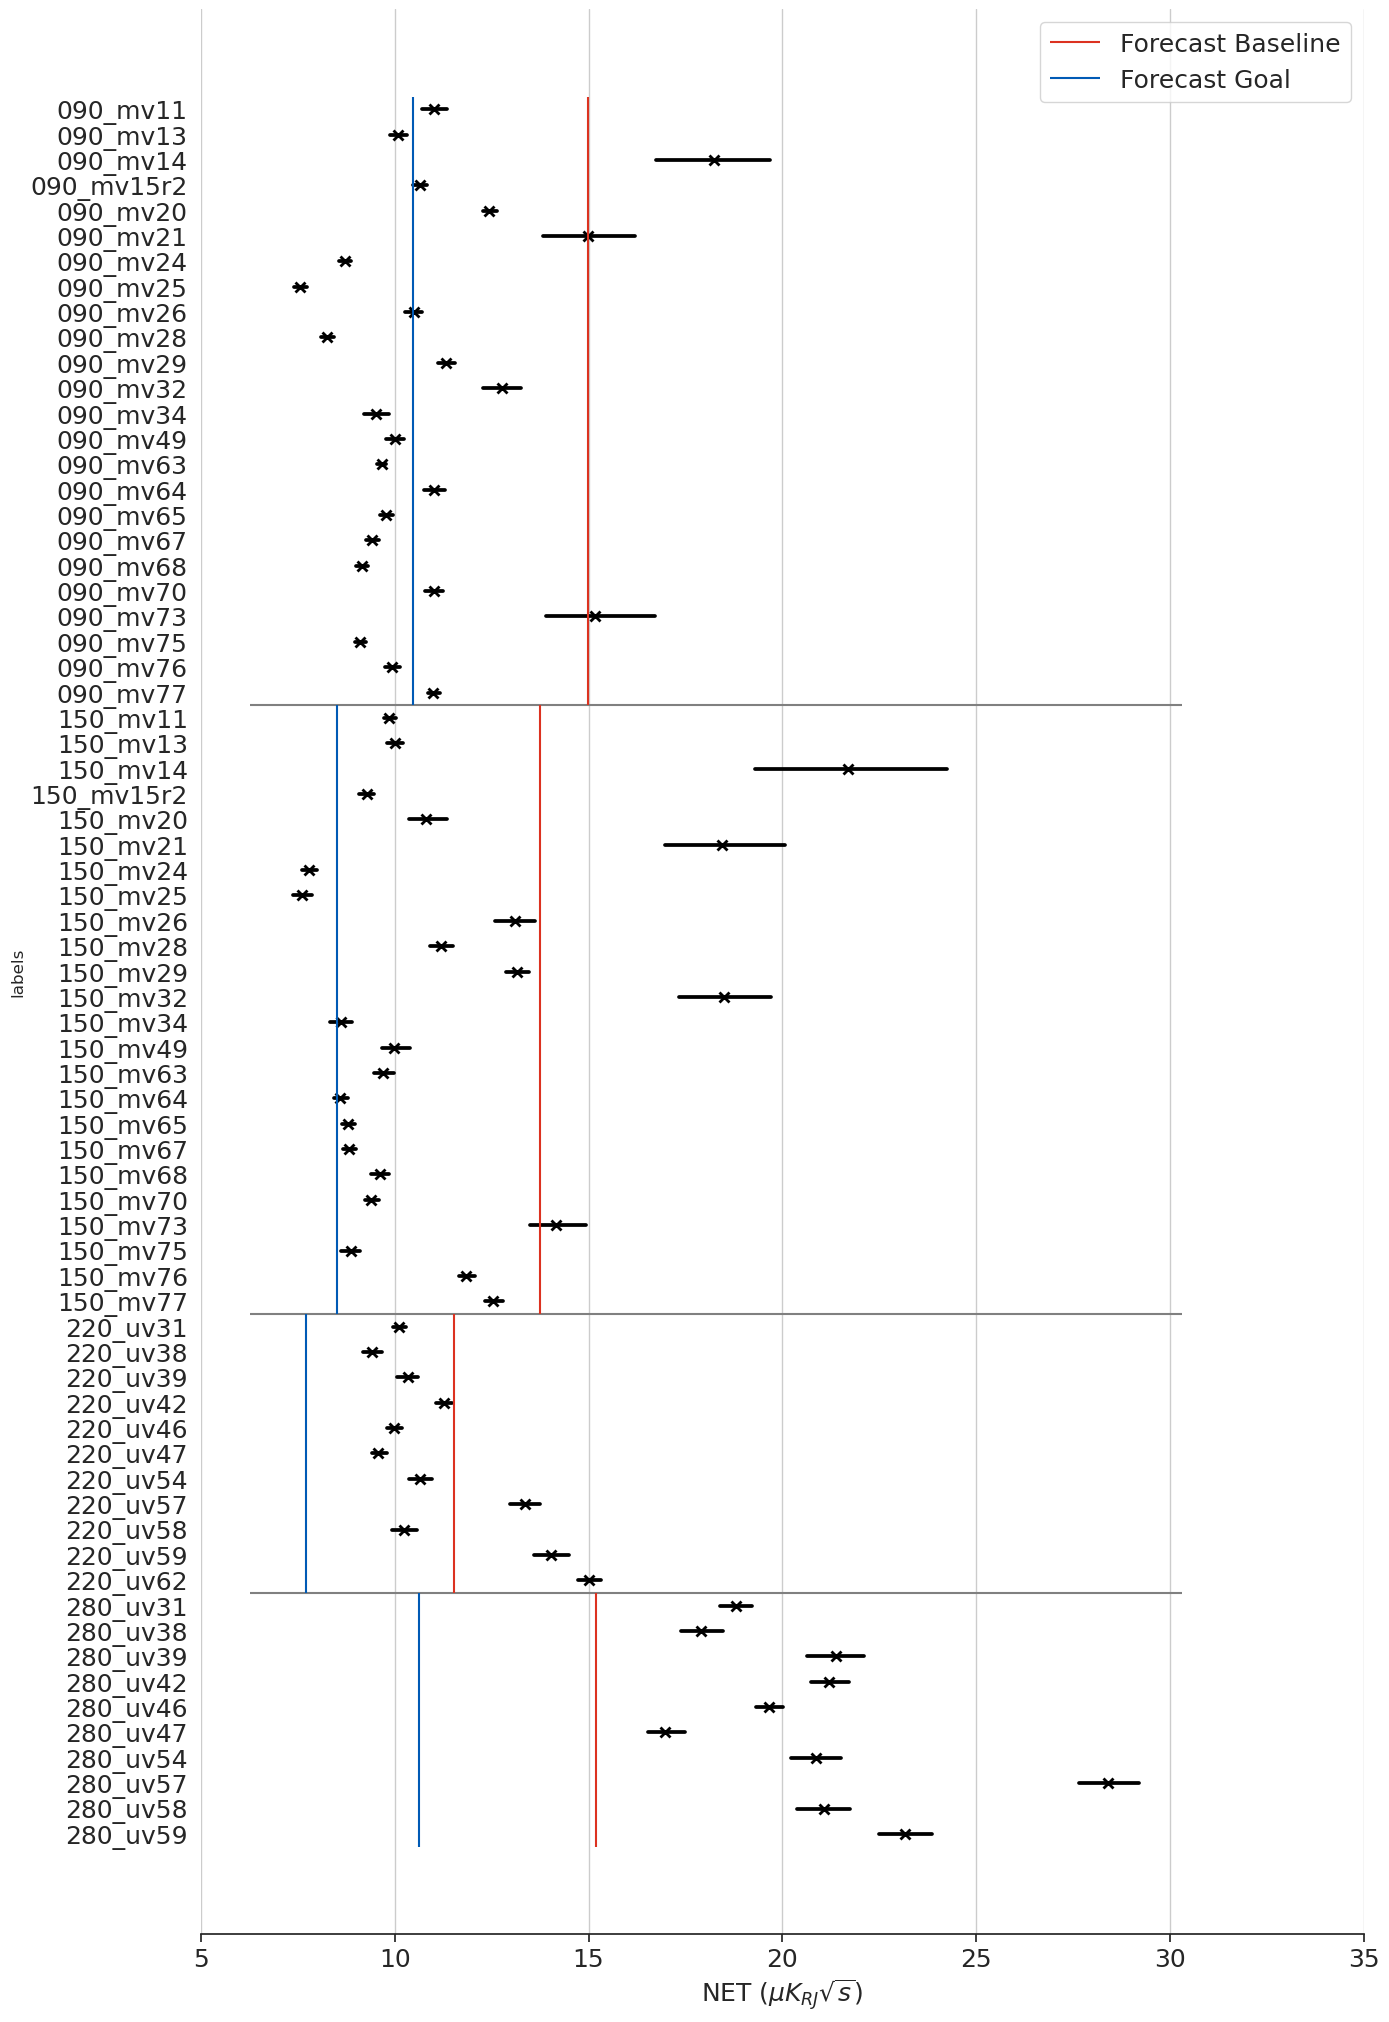

In [8]:
sns.set_theme(style="ticks")
fontsize = 18

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(15, 25))

# Add in points to show each observation
sns.pointplot(
    data=df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 5)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
    ),
    x="nets",
    y="labels",
    linestyle="none",
    marker="x",
    color="black",
    zorder=2,
)
# sns.pointplot(data = means_df, x="nets", y="labels", linestyle="none", marker="x", color="0.5", zorder=2)
# sns.stripplot(df.where((df.pwv/np.sin(np.deg2rad(df.el)) < 3) & (df.t_obs < t_cut_high.unix)), x="nets", y="labels", hue="pwv", zorder=1)


ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len(
    [label for label in set(df.labels.to_numpy()) if "150" in label]
)
pos_220 = pos_150 + len(
    [label for label in set(df.labels.to_numpy()) if "220" in label]
)
pos_280 = pos_220 + len(
    [label for label in set(df.labels.to_numpy()) if "280" in label]
)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

# pos_280 = len([label for label in set(df.labels.to_numpy()) if "280" in label]) + 0.8
# pos_220 = pos_280 + len([label for label in set(df.labels.to_numpy()) if "220" in label]) - 0.5
# pos_150 = pos_220 + len([label for label in set(df.labels.to_numpy()) if "150" in label]) - 1.0
# pos_090 = pos_150 + len([label for label in set(df.labels.to_numpy()) if "090" in label])

# pos_280 /= ymax
# pos_220 /= ymax
# pos_150 /= ymax
# pos_090 /= ymax

# 090 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline")
# plt.vlines(2.70*np.sqrt(12)/1.08, ymin = ymin, ymax = pos_090, label="v3r7 baseline", color="orange")
# plt.vlines(1.72*np.sqrt(12)/1.08, ymin = ymin, ymax = pos_090, label="v3r7 goal", color="blue")

# plt.vlines(4.31*np.sqrt(12)/1.08, ymin = ymin, ymax = pos_090, label="v3r0 baseline", color=c_base)
# plt.vlines(3.01*np.sqrt(12)/1.08, ymin = ymin, ymax = pos_090, label="v3r0 goal", color=c_goal)

# ax.axvspan(3.75*np.sqrt(12)/temp_conv_090.value, 5.37*np.sqrt(12)/temp_conv_090.value, ymin=pos_150, ymax=1, alpha=0.1, color='red', label="SO 2019 Forecasts")
plt.vlines(
    5.37 * np.sqrt(12) / temp_conv_090.value,
    ymin=ymin,
    ymax=pos_090,
    label="Forecast Baseline",
    color=c_base,
)
plt.vlines(
    3.75 * np.sqrt(12) / temp_conv_090.value,
    ymin=ymin,
    ymax=pos_090,
    label="Forecast Goal",
    color=c_goal,
)


# 150 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline")
# plt.vlines(3.21*np.sqrt(12)/1.0, ymin = pos_090, ymax = pos_150, label=None, color="orange")
# plt.vlines(2.03*np.sqrt(12)/1.0, ymin = pos_090, ymax = pos_150, label=None, color="blue")

# plt.vlines(4.01*np.sqrt(12)/1.0, ymin = pos_090, ymax = pos_150, label=None, color=c_base)
# plt.vlines(2.50*np.sqrt(12)/1.0, ymin = pos_090, ymax = pos_150, label=None, color=c_goal)

# ax.axvspan(4.18*np.sqrt(12)/temp_conv_150.value, 6.74*np.sqrt(12)/temp_conv_150.value, ymin=pos_220, ymax=pos_150, alpha=0.1, color='red')
plt.vlines(
    6.74 * np.sqrt(12) / temp_conv_150.value, ymin=pos_090, ymax=pos_150, color=c_base
)
plt.vlines(
    4.18 * np.sqrt(12) / temp_conv_150.value, ymin=pos_090, ymax=pos_150, color=c_goal
)

# 220 Goals
temp_conv = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline"
)
# plt.vlines(3.84*np.sqrt(6)/1.01, ymin = pos_150, ymax = pos_220, label=None, color="orange")
# plt.vlines(2.41*np.sqrt(6)/1.01, ymin = pos_150, ymax = pos_220, label=None, color="blue")

# plt.vlines(4.71*np.sqrt(6)/1.0, ymin = pos_150, ymax = pos_220, label=None, color=c_base)
# plt.vlines(3.16*np.sqrt(6)/1.0, ymin = pos_150, ymax = pos_220, label=None, color=c_goal)

# ax.axvspan(10.04*np.sqrt(6)/temp_conv_220.value, 15.00*np.sqrt(6)/temp_conv_220.value, ymin=pos_280, ymax=pos_220, alpha=0.1, color='red')
plt.vlines(
    15.00 * np.sqrt(6) / temp_conv_220.value, ymin=pos_150, ymax=pos_220, color=c_base
)
plt.vlines(
    10.04 * np.sqrt(6) / temp_conv_220.value, ymin=pos_150, ymax=pos_220, color=c_goal
)

# 280 Goals
temp_conv = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline"
)
# plt.vlines(8.61*np.sqrt(6)/1.0, ymin = pos_220, ymax = ymax, label=None, color="orange")
# plt.vlines(5.95*np.sqrt(6)/1.0, ymin = pos_220, ymax = ymax, label=None, color="blue")

# plt.vlines(6.60*np.sqrt(6)/1.0, ymin = pos_220, ymax = ymax, label=None, color=c_base)
# plt.vlines(4.63*np.sqrt(6)/1.0, ymin = pos_220, ymax = ymax, label=None, color=c_goal)

# ax.axvspan(25.11*np.sqrt(6)/temp_conv_280.value, 35.88*np.sqrt(6)/temp_conv_280.value, ymin=0, ymax=pos_280, alpha=0.1, color='red')
plt.vlines(
    35.88 * np.sqrt(6) / temp_conv_280.value, ymin=pos_220, ymax=ymax, color=c_base
)
plt.vlines(
    25.11 * np.sqrt(6) / temp_conv_280.value, ymin=pos_220, ymax=ymax, color=c_goal
)


plt.xlim(5, 35)

# Tweak the visual presentation
ax.xaxis.grid(True)
# ax.set(xlabel="NET ($\mu K_{RJ} \sqrt{s}$)", ylabel="", yticklabels=[])
ax.set_xlabel(r"NET ($\mu K_{RJ} \sqrt{s}$)", fontsize=fontsize)
#ax.set_ylabel("", fontsize=fontsize)
#ax.set_yticklabels([])
ax.tick_params(left=False, labelsize=fontsize)
sns.despine(trim=True, left=True)

plt.legend(fontsize=fontsize)
output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)
f.savefig(output_dir / "nets_f2f26.pdf", dpi=600, bbox_inches="tight")
f.savefig(output_dir / "nets_f2f26.png", dpi=600, bbox_inches="tight")

In [9]:
df_uk = copy.deepcopy(df)
nets = df.nets
for i, label in enumerate(set_labels):
    if "090" in label:
        nets[i] *= temp_conv_090
    elif "150" in label:
        nets[i] *= temp_conv_150
    elif "220" in label:
        nets[i] *= temp_conv_220
    elif "280" in label:
        nets[i] *= temp_conv_280

df_uk["nets"] = nets

/tmp/ipykernel_1290308/3529898240.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nets[i] *= temp_conv_090
/tmp/ipykernel_1290308/3529898240.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nets[i] *= temp_conv_090
/tmp/ipykernel_1290308/3529898240.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nets[i] *= temp_conv_090
/tmp/ipykernel_1290308/3529898240.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

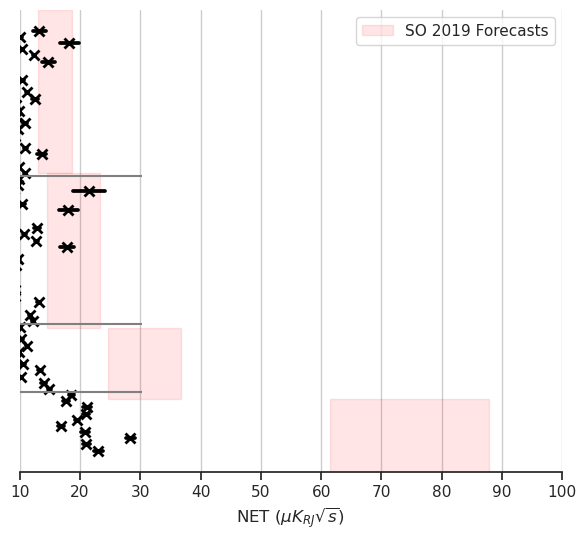

In [10]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Add in points to show each observation
sns.pointplot(
    data=df_uk.where(
        (df_uk.pwv / np.sin(np.deg2rad(df_uk.el)) < 3)
        & (df_uk.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_uk.t_obs)
    ),
    x="nets",
    y="labels",
    linestyle="none",
    marker="x",
    color="black",
    zorder=2,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len(
    [label for label in set(df.labels.to_numpy()) if "150" in label]
)
pos_220 = pos_150 + len(
    [label for label in set(df.labels.to_numpy()) if "220" in label]
)
pos_280 = pos_220 + len(
    [label for label in set(df.labels.to_numpy()) if "280" in label]
)

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")

pos_280 = len([label for label in set(df.labels.to_numpy()) if "280" in label]) + 0.8
pos_220 = (
    pos_280
    + len([label for label in set(df.labels.to_numpy()) if "220" in label])
    - 0.5
)
pos_150 = (
    pos_220
    + len([label for label in set(df.labels.to_numpy()) if "150" in label])
    - 1.0
)
pos_090 = pos_150 + len(
    [label for label in set(df.labels.to_numpy()) if "090" in label]
)

pos_280 /= ymax
pos_220 /= ymax
pos_150 /= ymax
pos_090 /= ymax

# 090 Goals
ax.axvspan(
    3.75 * np.sqrt(12),
    5.37 * np.sqrt(12),
    ymin=pos_150,
    ymax=1,
    alpha=0.1,
    color="red",
    label="SO 2019 Forecasts",
)

# 150 Goals
ax.axvspan(
    4.18 * np.sqrt(12) / 1.0,
    6.74 * np.sqrt(12) / 1.0,
    ymin=pos_220,
    ymax=pos_150,
    alpha=0.1,
    color="red",
)

# 220 Goals
ax.axvspan(
    10.04 * np.sqrt(6) / 1.0,
    15.00 * np.sqrt(6) / 1.0,
    ymin=pos_280,
    ymax=pos_220,
    alpha=0.1,
    color="red",
)


# 280 Goals
ax.axvspan(
    25.11 * np.sqrt(6) / 1.0,
    35.88 * np.sqrt(6) / 1.0,
    ymin=0,
    ymax=pos_280,
    alpha=0.1,
    color="red",
)

plt.xlim(10, 100)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel=r"NET ($\mu K_{RJ} \sqrt{s}$)", ylabel="", yticklabels=[])
ax.tick_params(left=False)
sns.despine(trim=True, left=True)

plt.legend()
#f.savefig("./plts/nets/nets_APS_uK.pdf", dpi=600, bbox_inches="tight")
#f.savefig("./plts/nets/nets_APS_uK.png", dpi=600, bbox_inches="tight")

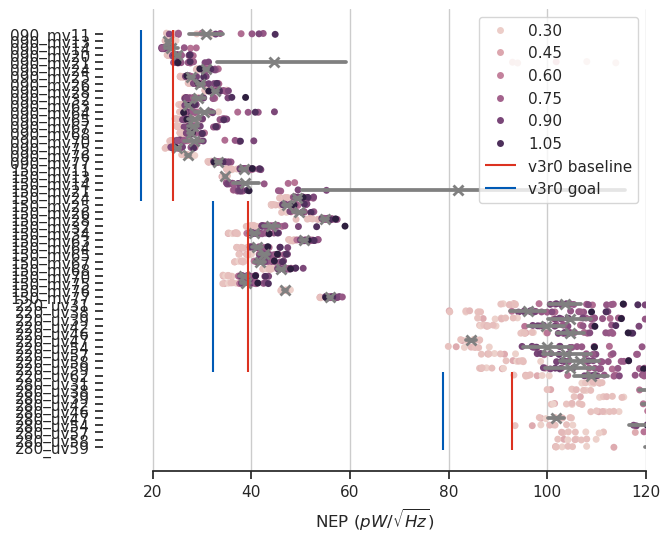

In [11]:
t_cut_low = Time("2024-09-12T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-05-03T00:00:00", format="isot", scale="utc")

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Add in points to show each observation
sns.pointplot(
    data=df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
    ),
    x="neps",
    y="labels",
    linestyle="none",
    marker="x",
    color="0.5",
    zorder=2,
)
sns.stripplot(
    df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
    ),
    x="neps",
    y="labels",
    hue="pwv",
    zorder=1,
)


ymax, ymin = ax.get_ylim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len(
    [label for label in set(df.labels.to_numpy()) if "150" in label]
)
pos_220 = pos_150 + len(
    [label for label in set(df.labels.to_numpy()) if "220" in label]
)
pos_280 = pos_220 + len(
    [label for label in set(df.labels.to_numpy()) if "280" in label]
)

# 90 Goals
plt.vlines(24.04, ymin=ymin, ymax=pos_090, label="v3r0 baseline", color=c_base)
plt.vlines(17.70, ymin=ymin, ymax=pos_090, label="v3r0 goal", color=c_goal)

# 150 Goals
plt.vlines(39.25, ymin=pos_090, ymax=pos_150, label=None, color=c_base)
plt.vlines(32.13, ymin=pos_090, ymax=pos_150, label=None, color=c_goal)

# 220 Goals
plt.vlines(92.86, ymin=pos_150, ymax=pos_220, label=None, color=c_base)
plt.vlines(78.89, ymin=pos_150, ymax=pos_220, label=None, color=c_goal)

# 280 Goals
plt.vlines(108.63, ymin=pos_220, ymax=ymax, label=None, color=c_base)
plt.vlines(99.79, ymin=pos_220, ymax=ymax, label=None, color=c_goal)


plt.xlim(10, 120)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel=r"NEP ($pW / \sqrt{Hz}$)", ylabel="")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/nets/neps.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/nets/neps.png", dpi=600, bbox_inches='tight')

## Combined by Frequency

In [12]:
obs_ids_090 = []
obs_ids_150 = []

for key in net_dict.keys():
    if "mv" in key:
        obs_ids_090.append(net_dict[key]["090"]["obs"])
        obs_ids_150.append(net_dict[key]["150"]["obs"])

obs_ids_220 = []
obs_ids_280 = []

for key in net_dict.keys():
    if "uv" in key:
        obs_ids_220.append(net_dict[key]["220"]["obs"])
        obs_ids_280.append(net_dict[key]["280"]["obs"])

In [14]:
times_090 = mu.get_matching_obs(obs_ids_090)
times_150 = mu.get_matching_obs(obs_ids_150)

times_220 = mu.get_matching_obs(obs_ids_220)
times_280 = mu.get_matching_obs(obs_ids_280)

In [ ]:
"""
uv_keys = ['uv47', 'uv31', 'uv38', 'uv46', 'uv42', 'uv39']
j=26
for i in range(len(uv_keys)):
    print(net_dict[uv_keys[i]]["280"]["nets"][times_280[i][j]])
    print(net_dict[uv_keys[i]]["280"]["obs"][times_280[i][j]])
    print(net_dict[uv_keys[i]]["280"]["pwv"][times_280[i][j]]/np.sin(np.deg2rad(net_dict[uv_keys[i]]["280"]["el"][times_280[i][j]])))
"""

In [15]:
nets_090 = np.zeros(times_090.shape)
nets_150 = np.zeros(times_150.shape)
t_obs_090 = np.zeros(times_090.shape[1])
t_obs_150 = np.zeros(times_150.shape[1])
new_obs_ids_090 = []
new_obs_ids_150 = []
ndets_090 = np.zeros(times_090.shape)
ndets_150 = np.zeros(times_150.shape)
pwvs_sinel_090 = 0
pwvs_090 = 0
pwvs_sinel_150 = 0
pwvs_150 = 0

temp_conv_090 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline"
)
temp_conv_150 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline"
)
temp_conv_220 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline"
)
temp_conv_280 = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline"
)
i = 0
for key in net_dict.keys():
    if "mv" in key:
        nets_090[i] = (
            np.array(net_dict[key]["090"]["nets"])[times_090[i]] * temp_conv_090
        )
        ndets_090[i] += np.array(net_dict[key]["090"]["ndets"])[times_090[i]]
        if i == 0:
            pwvs_sinel_090 = (
                (np.array(net_dict[key]["090"]["pwv"])[times_090[i]])
                / np.sin(np.deg2rad(np.array(net_dict[key]["090"]["el"])))[times_090[i]]
            )
            pwvs_090 = np.array(net_dict[key]["090"]["pwv"])[times_090[i]]
            for j, obs_id in enumerate(np.array(obs_ids_090[i])[times_090[i]]):
                t_obs_090[j] = obs_id.split("_")[1]
                new_obs_ids_090.append(obs_id)

        i += 1

i = 0
for key in net_dict.keys():
    if "mv" in key:
        nets_150[i] = (
            np.array(net_dict[key]["150"]["nets"])[times_150[i]] * temp_conv_150
        )
        ndets_150[i] += np.array(net_dict[key]["150"]["ndets"])[times_150[i]]
        if i == 0:
            pwvs_sinel_150 = (
                (np.array(net_dict[key]["150"]["pwv"])[times_150[i]])
                / np.sin(np.deg2rad(np.array(net_dict[key]["150"]["el"])))[times_150[i]]
            )
            pwvs_150 = np.array(net_dict[key]["150"]["pwv"])[times_150[i]]
            for j, obs_id in enumerate(np.array(obs_ids_150[i])[times_150[i]]):
                t_obs_150[j] = obs_id.split("_")[1]
                new_obs_ids_150.append(obs_id)

        i += 1

nets_220 = np.zeros(times_220.shape)
nets_280 = np.zeros(times_280.shape)
t_obs_220 = np.zeros(times_220.shape[1])
t_obs_280 = np.zeros(times_280.shape[1])
new_obs_ids_220 = []
new_obs_ids_280 = []
ndets_220 = np.zeros(times_220.shape)
ndets_280 = np.zeros(times_280.shape)
pwvs_sinel_220 = 0
pwvs_220 = 0
pwvs_sinel_280 = 0
pwvs_280 = 0
i = 0
for key in net_dict.keys():
    if "uv" in key:
        nets_220[i] = (
            np.array(net_dict[key]["220"]["nets"])[times_220[i]] * temp_conv_220
        )
        ndets_220[i] += np.array(net_dict[key]["220"]["ndets"])[times_220[i]]
        if i == 0:
            pwvs_sinel_220 = (
                (np.array(net_dict[key]["220"]["pwv"])[times_220[i]])
                / np.sin(np.deg2rad(np.array(net_dict[key]["220"]["el"])))[times_220[i]]
            )
            pwvs_220 = np.array(net_dict[key]["220"]["pwv"])[times_220[i]]
            for j, obs_id in enumerate(np.array(obs_ids_220[i])[times_220[i]]):
                t_obs_220[j] = obs_id.split("_")[1]
                new_obs_ids_220.append(obs_id)

        i += 1

i = 0
for key in net_dict.keys():
    if "uv" in key:
        nets_280[i] = (
            np.array(net_dict[key]["280"]["nets"])[times_280[i]] * temp_conv_280
        )
        ndets_280[i] += np.array(net_dict[key]["280"]["ndets"])[times_280[i]]

        if i == 0:
            pwvs_sinel_280 = (
                (np.array(net_dict["uv38"]["280"]["pwv"])[times_280[i]])
                / np.sin(np.deg2rad(np.array(net_dict["uv38"]["280"]["el"])))[
                    times_280[i]
                ]
            )
            pwvs_280 = np.array(net_dict["uv38"]["280"]["pwv"])[times_280[i]]
            for j, obs_id in enumerate(np.array(obs_ids_280[i])[times_280[i]]):
                t_obs_280[j] = obs_id.split("_")[1]
                new_obs_ids_280.append(obs_id)

        i += 1


nets_090_comb = np.zeros(times_090.shape[1])
nets_090 = nets_090.T
ndets_090 = np.sum(ndets_090, axis=0)
new_obs_ids_090 = np.array(new_obs_ids_090)

nets_150_comb = np.zeros(times_150.shape[1])
nets_150 = nets_150.T
ndets_150 = np.sum(ndets_150, axis=0)
new_obs_ids_150 = np.array(new_obs_ids_150)

for i in range(len(nets_090)):
    nets_090_comb[i] = np.sum(1 / (nets_090[i]) ** 2) ** (-1 / 2)
for i in range(len(nets_150)):
    nets_150_comb[i] = np.sum(1 / (nets_150[i]) ** 2) ** (-1 / 2)

nets_220_comb = np.zeros(times_220.shape[1])
nets_220 = nets_220.T
ndets_220 = np.sum(ndets_220, axis=0)
new_obs_ids_220 = np.array(new_obs_ids_220)

nets_280_comb = np.zeros(times_280.shape[1])
nets_280 = nets_280.T
ndets_280 = np.sum(ndets_280, axis=0)
new_obs_ids_280 = np.array(new_obs_ids_280)

for i in range(len(nets_220)):
    nets_220_comb[i] = np.sum(1 / (nets_220[i]) ** 2) ** (-1 / 2)
for i in range(len(nets_280)):
    nets_280_comb[i] = np.sum(1 / (nets_280[i]) ** 2) ** (-1 / 2)

In [16]:
nets = np.concatenate([nets_090_comb, nets_150_comb, nets_220_comb, nets_280_comb])
pwvs = np.concatenate([pwvs_090, pwvs_150, pwvs_220, pwvs_280])
pwvs_sinel = np.concatenate(
    [pwvs_sinel_090, pwvs_sinel_150, pwvs_sinel_220, pwvs_sinel_280]
)
labels = np.concatenate(
    [
        ["f090"] * len(pwvs_090),
        ["f150"] * len(pwvs_150),
        ["f220"] * len(pwvs_220),
        ["f280"] * len(pwvs_280),
    ]
)
t_obs = np.concatenate([t_obs_090, t_obs_150, t_obs_220, t_obs_280])
ndets = np.concatenate([ndets_090, ndets_150, ndets_220, ndets_280])
obs_ids = np.concatenate(
    [new_obs_ids_090, new_obs_ids_150, new_obs_ids_220, new_obs_ids_280]
)


df_freq = pd.DataFrame(
    {
        "labels": labels,
        "nets": nets,
        "pwv": pwvs,
        "pwvs_sinel": pwvs_sinel,
        "t_obs": t_obs,
        "ndets": ndets,
        "obs_ids": obs_ids,
    }
)

In [20]:
nets

array([], dtype=float64)

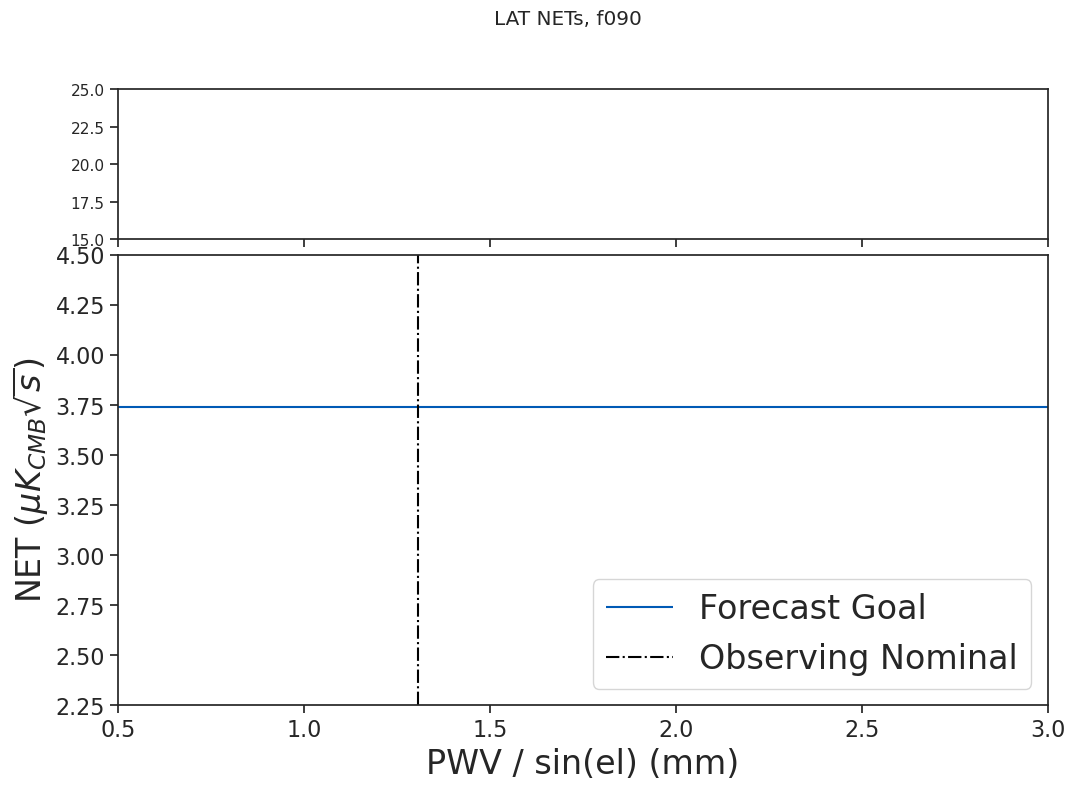

In [17]:
fig, (axu, axd) = plt.subplots(
    ncols=1,
    nrows=2,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw=dict(height_ratios=[1, 3], wspace=0, hspace=0.05),
)

fontsize = 24


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    ax=axd,
    data=df_freq.where(
        (df_freq.labels == "f090")
        & (df_freq.pwvs_sinel < 30)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 15)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
    fit_reg=False,
)

sns.regplot(
    ax=axu,
    data=df_freq.where(
        (df_freq.labels == "f090")
        & (df_freq.pwvs_sinel < 30)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 15)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (2.25, 4.5)
axd.set_ylim(ymin, ymax)
axu.set_ylim(15, 25)
plt.xticks(fontsize=fontsize * 2 / 3)
plt.yticks(fontsize=fontsize * 2 / 3)

# plt.plot(wafer_net_c["pwv_sin_el"], 1e6*wafer_net_c['baseline']['MF']['MF_1']/np.sqrt(12), linestyle="--", label='v3r8 090 Baseline', color=c_base)
# plt.plot(wafer_net_c["pwv_sin_el"], 1e6*wafer_net_c['goal']['MF']['MF_1']/np.sqrt(12), linestyle="--", label='v3r8 090 Goal', color=c_goal)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline"
)
temp_conv_goal = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="goal")

# plt.hlines(4.31*temp_conv_base, xmin=0.5, xmax = xmax, label="Forecast Baseline", color=c_base)
plt.hlines(
    3.01 * temp_conv_goal, xmin=0.5, xmax=xmax, label="Forecast Goal", color=c_goal
)

# axd.axvspan(0, 3, ymin=(3.01*temp_conv_goal.value - 2.25)/2.25, ymax=1, alpha=0.1, color='red', label="SO 2019 Forecast")

# plt.vlines(1/np.sin(np.deg2rad(50)), ymin, ymax, color="black", linestyle="dashdot", label = "PWV/sin(el) = 1/sin(50)")
plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="Observing Nominal",
)

plt.xlabel("PWV / sin(el) (mm)", fontsize=fontsize)
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)", fontsize=fontsize)

axu.set(xlabel="", ylabel="")

plt.legend(loc="lower right", fontsize=fontsize)

fig.suptitle("LAT NETs, f090")

#plt.savefig("./plts/nets/APS_nets_090.pdf", dpi=600, bbox_inches="tight")
#plt.savefig("./plts/nets/APS_nets_090.png", dpi=600, bbox_inches="tight")
plt.show()

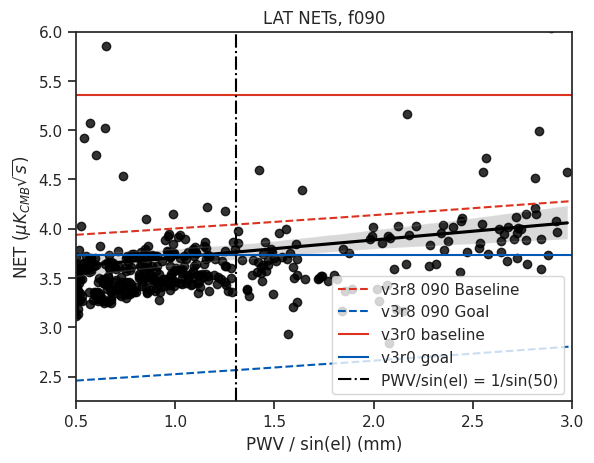

In [33]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f090")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 15)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f090")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 15)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["MF"]["MF_1"] / np.sqrt(12),
    linestyle="--",
    label="v3r8 090 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["MF"]["MF_1"] / np.sqrt(12),
    linestyle="--",
    label="v3r8 090 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline"
)
temp_conv_goal = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="goal")

# plt.hlines(2*4.31*temp_conv_base, xmin=0.5, xmax = xmax, label="Comm. Req.", color="black", linestyle="--")
plt.hlines(
    4.31 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(3.01 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (2.25, np.round(1.1 * 4.31 * temp_conv_base))
plt.ylim(ymin, ymax)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

plt.legend(loc="lower right")

plt.title("LAT NETs, f090")

# plt.savefig("./plts/nets/nets_090_no_zoom.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/nets/nets_090_no_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

NameError: name 'df_freq' is not defined

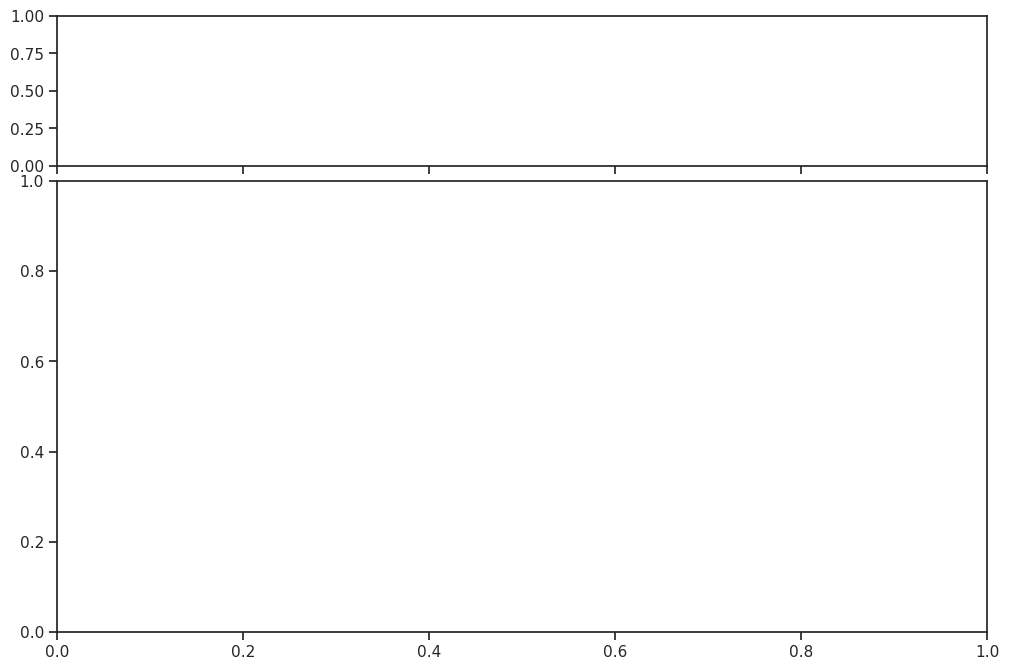

In [15]:
fig, (axu, axd) = plt.subplots(
    ncols=1,
    nrows=2,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw=dict(height_ratios=[1, 3], wspace=0, hspace=0.05),
)


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    ax=axd,
    data=df_freq.where(
        (df_freq.labels == "f150")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 10)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
    fit_reg=False,
)

sns.regplot(
    ax=axu,
    data=df_freq.where(
        (df_freq.labels == "f150")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 10)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (3, 6.5)
axd.set_ylim(ymin, ymax)
axu.set_ylim(30, 50)

# plt.plot(wafer_net_c["pwv_sin_el"], 1e6*wafer_net_c['baseline']['MF']['MF_2']/np.sqrt(12), linestyle='--', label='v3r8 150 Baseline', color=c_base)
# plt.plot(wafer_net_c["pwv_sin_el"], 1e6*wafer_net_c['goal']['MF']['MF_2']/np.sqrt(12), linestyle='--', label='v3r8 150 Goal', color=c_goal)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline"
)
temp_conv_goal = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="goal")

# plt.hlines(4.01*temp_conv_base, xmin=0.5, xmax = xmax, label="v3r0 baseline", color=c_base)
# plt.hlines(2.50*temp_conv_goal, xmin=0.5, xmax = xmax, label="v3r0 goal", color=c_goal)

axd.axvspan(
    0,
    3,
    ymin=(2.5 * temp_conv_goal.value - 3.0) / 3.5,
    ymax=1,
    alpha=0.1,
    color="red",
    label="Instrument Model",
)

# plt.vlines(1/np.sin(np.deg2rad(50)), ymin, ymax, color="black", linestyle="dashdot", label = "PWV/sin(el) = 1/sin(50)")
plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="Observing Nominal",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

axu.set(xlabel="", ylabel="")

plt.legend(loc="lower right")

fig.suptitle("LAT NETs, f150")

# plt.savefig("./plts/reanalysis/nets/nets_150.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/reanalysis/nets/nets_150.png", dpi=600, bbox_inches='tight')
plt.show()

In [89]:
(2.5 * temp_conv_goal.value - 3.0) / 3.5

np.float64(0.356740466680536)

In [ ]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f150")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 10)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f150")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 10)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["MF"]["MF_2"] / np.sqrt(12),
    linestyle="--",
    label="v3r8 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["MF"]["MF_2"] / np.sqrt(12),
    linestyle="--",
    label="v3r8 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline"
)
temp_conv_goal = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="goal")

# plt.hlines(2*4.01*temp_conv_base, xmin=0.5, xmax = xmax, label="Comm. Rec.", color="black", linestyle="--")
plt.hlines(
    4.01 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(2.50 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (2.25, np.round(1.1 * 4.01 * temp_conv_base))
plt.ylim(ymin, ymax)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

plt.legend(loc="lower right")

plt.title("LAT NETs, f150")

# plt.savefig("./plts/nets/nets_150_no_zoom.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/nets/nets_150_no_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

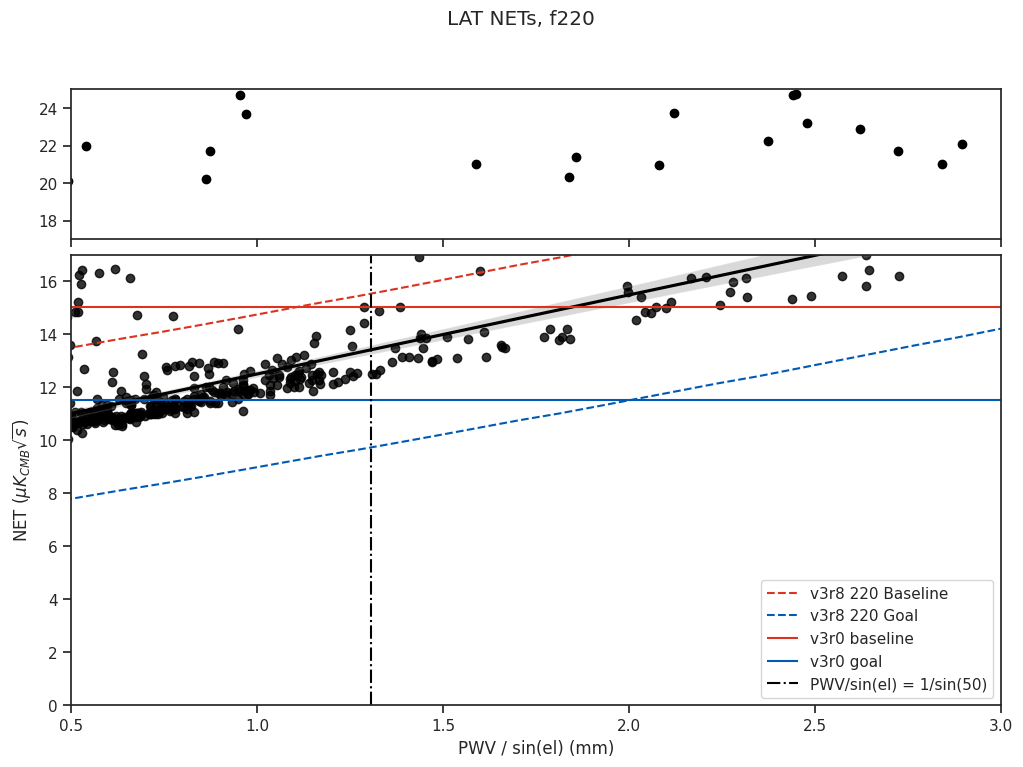

In [36]:
fig, (axu, axd) = plt.subplots(
    ncols=1,
    nrows=2,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw=dict(height_ratios=[1, 3], wspace=0, hspace=0.05),
)


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    ax=axd,
    data=df_freq.where(
        (df_freq.labels == "f220")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 20)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    ax=axu,
    data=df_freq.where(
        (df_freq.labels == "f220")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 20)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (0, 17)
axd.set_ylim(ymin, ymax)
axu.set_ylim(17, 25)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["UHF"]["UHF_1"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 220 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["UHF"]["UHF_1"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 220 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline"
)
temp_conv_goal = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="goal"
)

plt.hlines(
    4.71 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(3.61 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

axu.set(xlabel="", ylabel="")

plt.legend(loc="lower right")

fig.suptitle("LAT NETs, f220")

# plt.savefig("./plts/nets/nets_220.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/nets/nets_220.png", dpi=600, bbox_inches='tight')
plt.show()

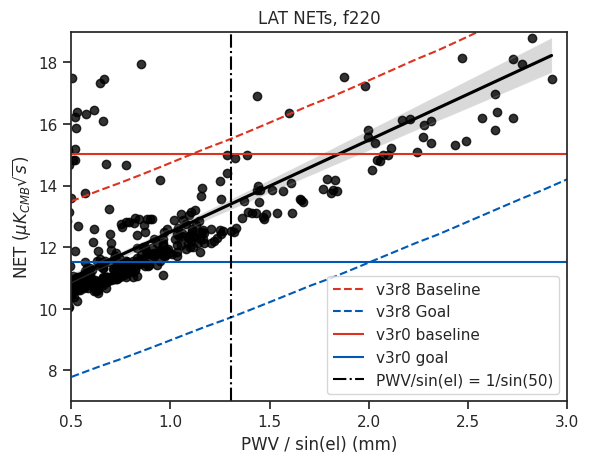

In [37]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f220")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 20)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f220")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 20)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["UHF"]["UHF_1"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["UHF"]["UHF_1"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline"
)
temp_conv_goal = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="goal"
)

# plt.hlines(2*4.71*temp_conv_base, xmin=0.5, xmax = xmax, label="Comm. Rec.", color="black", linestyle="--")
plt.hlines(
    4.71 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(3.61 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (7, np.round(1.25 * 4.71 * temp_conv_base))
plt.ylim(ymin, ymax)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

plt.legend(loc="lower right")

plt.title("LAT NETs, f220")

# plt.savefig("./plts/nets/nets_220_no_zoom.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/nets/nets_220_no_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

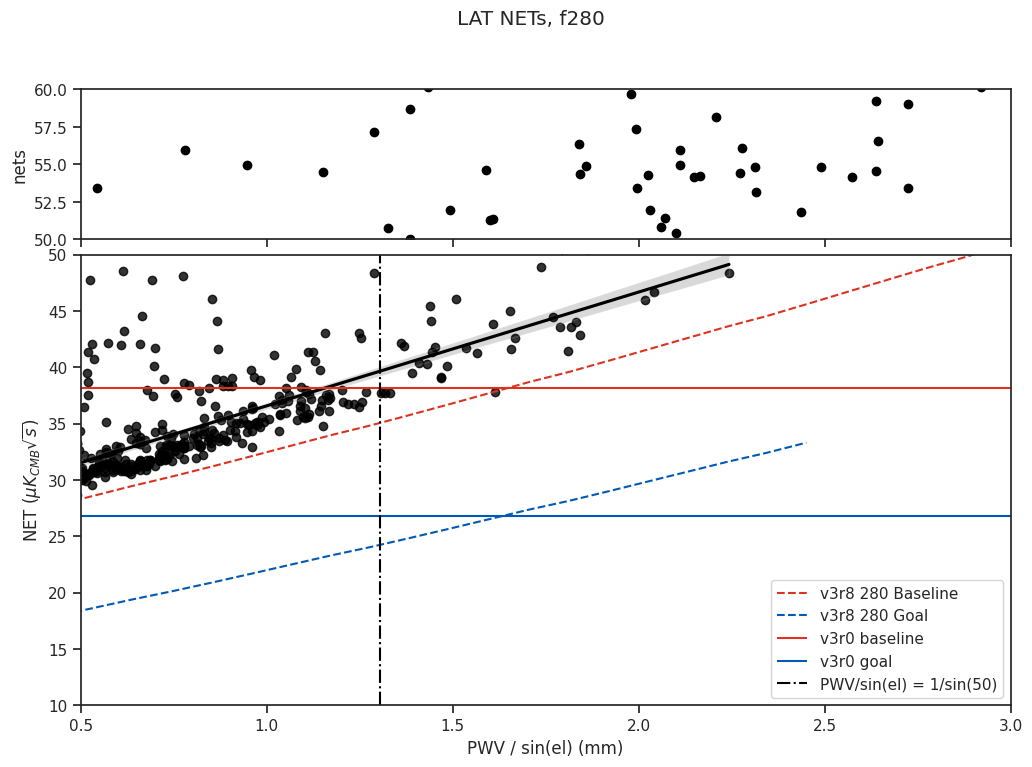

In [38]:
fig, (axu, axd) = plt.subplots(
    ncols=1,
    nrows=2,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw=dict(height_ratios=[1, 3], wspace=0, hspace=0.05),
)


sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
sns.regplot(
    ax=axd,
    data=df_freq.where(
        (df_freq.labels == "f280")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 50)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    ax=axd,
    data=df_freq.where(
        (df_freq.labels == "f280")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 50)
        & (df_freq.ndets > 3500)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "green"},
    scatter_kws={"color": "green"},
)

sns.regplot(
    ax=axu,
    data=df_freq.where(
        (df_freq.labels == "f280")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 50)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (10, 50)
axd.set_ylim(ymin, ymax)
axu.set_ylim(50, 60)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["UHF"]["UHF_2"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 280 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["UHF"]["UHF_2"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 280 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline"
)
temp_conv_goal = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="goal"
)

plt.hlines(
    6.60 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(4.63 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

plt.legend()

fig.suptitle("LAT NETs, f280")

# plt.savefig("./plts/nets/nets_280.pdf", dpi=600, bbox_inches='tight')
# plt.savefig("./plts/nets/nets_280.png", dpi=600, bbox_inches='tight')
plt.show()

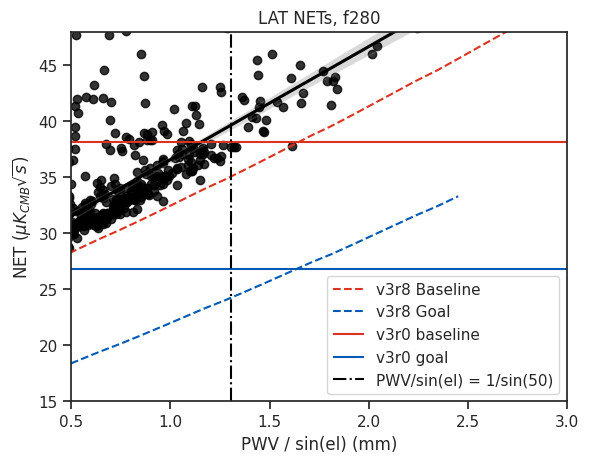

In [39]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis

# Plot sepal width as a function of sepal_length across days
# Plot sepal width as a function of sepal_length across days
sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f280")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets < 50)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"color": "black"},
    scatter_kws={"color": "black"},
)

sns.regplot(
    data=df_freq.where(
        (df_freq.labels == "f280")
        & (df_freq.pwvs_sinel < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df_freq.nets > 50)
    ),
    x="pwvs_sinel",
    y="nets",
    line_kws={"alpha": 0},
    scatter_kws={"alpha": 1, "color": "black"},
    fit_reg=False,
)

plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["baseline"]["UHF"]["UHF_2"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 Baseline",
    color=c_base,
)
plt.plot(
    wafer_net_c["pwv_sin_el"],
    1e6 * wafer_net_c["goal"]["UHF"]["UHF_2"] / np.sqrt(6),
    linestyle="--",
    label="v3r8 Goal",
    color=c_goal,
)

temp_conv_base = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline"
)
temp_conv_goal = mu.temp_conv(
    T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="goal"
)

# plt.hlines(2*6.60*temp_conv_base, xmin=0.5, xmax = xmax, label="Comm. Rec.", color="black", linestyle="--")
plt.hlines(
    6.60 * temp_conv_base, xmin=0.5, xmax=xmax, label="v3r0 baseline", color=c_base
)
plt.hlines(4.63 * temp_conv_goal, xmin=0.5, xmax=xmax, label="v3r0 goal", color=c_goal)

xmax = 3.0
plt.xlim(0.5, xmax)
ymin, ymax = (15, np.round(1.25 * 6.60 * temp_conv_base))
plt.ylim(ymin, ymax)

plt.vlines(
    1 / np.sin(np.deg2rad(50)),
    ymin,
    ymax,
    color="black",
    linestyle="dashdot",
    label="PWV/sin(el) = 1/sin(50)",
)

plt.xlabel("PWV / sin(el) (mm)")
plt.ylabel(r"NET ($\mu K_{CMB} \sqrt{s}$)")

plt.legend(loc="lower right")

plt.title("LAT NETs, f280")

plt.savefig("./plts/nets/nets_280_no_zoom.pdf", dpi=600, bbox_inches="tight")
plt.savefig("./plts/nets/nets_280_no_zoom.png", dpi=600, bbox_inches="tight")
plt.show()

## NEPs

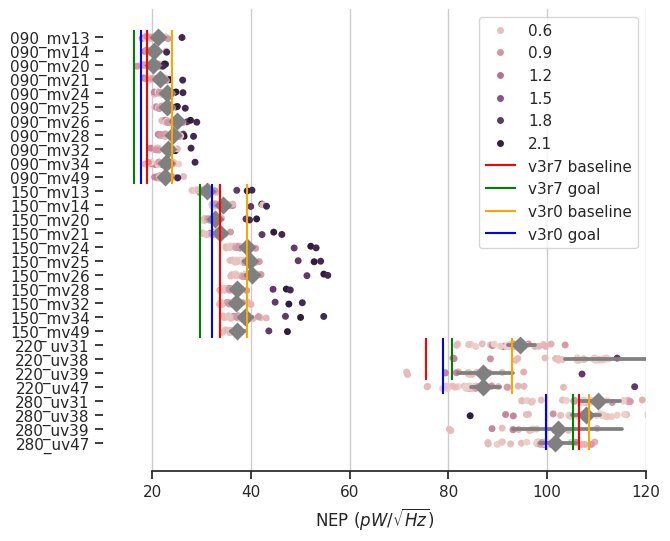

# Indv Det NETs

In [69]:
import glob

import latcom.utils.net_utils as nu
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    pwv_interp,
    so_nominal_tubes,
)

result_path = sorted(glob.glob("../abscals/results_*.pk"))[-1]

with open(result_path, "rb") as f:
    result_dict = pk.load(f)

ctx = core.Context("../ctxs/smurf_det_preproc.yaml")
start = dt.datetime(2026, 6, 21, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 12, 21, tzinfo=dt.timezone.utc)

obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

pwv = pwv_interp()
my_ot = "i6"
obs_ctx_list = []

for i, obs in enumerate(obs_list):
    ot = str(obs["obs_id"]).split("_")[2][3:]
    if ot != my_ot:
        continue
    obs_id = str(obs["obs_id"])
    if ot in so_nominal_tubes:
        obs_ctx_list.append((obs_id, "../ctxs/preprocess_nominal.yaml"))
    elif ot in aso_tubes:
        obs_ctx_list.append((obs_id, "../ctxs/preprocess_aso.yaml"))
    elif ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../ctxs/preprocess_lf.yaml"))

In [70]:
results = []
for obs_ctx in obs_ctx_list:
    results.append(nu.get_nets(obs_ctx, abscal_list=list(result_dict.keys()), pwv=pwv))

ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v1/preprocessing/archives_nominal//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782000562_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f090'}




No meta data for obs obs_1782000562_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v1/preprocessing/archives_nominal//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782000562_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}




No meta data for obs obs_1782000562_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v1/preprocessing/archives_nominal//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782000562_lati6_111', 'dets:stream_id': 'ufm_mv25', 'dets:wafer.bandpass': 'f090'}




...

No meta data for obs obs_1782702211_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v1/preprocessing/archives_nominal//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782702211_lati6_111', 'dets:stream_id': 'ufm_mv26', 'dets:wafer.bandpass': 'f090'}




No meta data for obs obs_1782702211_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v1/preprocessing/archives_nominal//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1782702211_lati6_111', 'dets:stream_id': 'ufm_mv26', 'dets:wafer.bandpass': 'f150'}




No meta data for obs obs_1782702211_lati6_111


In [73]:
obs_ctx_list[0]

('obs_1782000562_lati6_111', '../ctxs/preprocess_nominal.yaml')

Text(0.5, 0, 'NEP (aW/rt(Hz))')

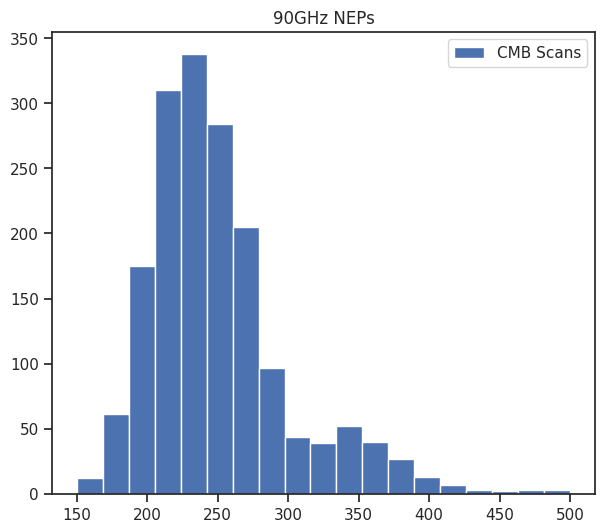

In [38]:
f, ax = plt.subplots(figsize=(7, 6))

# baseline_r0 = 24.04
# baseline_r7 = 18.99

# goal_r0 = 17.70
# goal_r7 = 16.37

# plt.hist(df[flags]*1e6/baseline_r0, bins = np.linspace(0,2, 20), label = "CMB Scans")
plt.hist(
    df.where((df.pwv < 3) & (np.char.find(str(df.labels), "090") != -1)).indv_nets,
    bins=np.linspace(150, 500, 20),
    label="CMB Scans",
)
ymax, ymin = ax.get_ylim()
# plt.vlines(baseline_r7/baseline_r0, ymin, ymax, label="baseline v3r7", color="red")
# plt.vlines(goal_r7/baseline_r0, ymin, ymax, label="goal v3r7", color="green")
# plt.vlines(baseline_r0/baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
# plt.vlines(goal_r0/baseline_r0, ymin, ymax, label="goal v3r0", color="blue")
# plt.xlabel("NEP/baseline")
plt.title("90GHz NEPs")
plt.legend()


def normalize(x):
    return x / baseline_r0


def denorm(x):
    return x * baseline_r0


secax = ax.secondary_xaxis("top", functions=(denorm, normalize))
secax.set_xlabel("NEP (aW/rt(Hz))")

# f.savefig("./plts/nets/neps_090.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/nets/neps_090.png", dpi=600, bbox_inches='tight')

In [40]:
net_dict.keys()

dict_keys(['mv13', 'mv20', 'mv34', 'mv32', 'mv14', 'mv49', 'mv26', 'mv11', 'mv25', 'mv24', 'mv28', 'mv21', 'uv46', 'uv38', 'uv31', 'uv47', 'uv42', 'uv39', 'ufm'])

In [161]:
nep_labels = []
neps = []
cals = []
neis = []
obs = []
pwvs = []
els = []

freqs = ["090", "150", "220", "280"]
ufms = sorted(result_dict.keys())

for (
    freq
) in freqs:  # This is slighly inefficient but the ezest way to sort by freq then ufm
    for ufm in ufms:
        for key in net_dict.keys():
            if ufm not in key:
                continue
            for sub_key in net_dict[key].keys():
                if freq not in sub_key:
                    continue
                cur_abscals = np.array(net_dict[key][sub_key]["raw_cal"])
                cur_nets = np.array(net_dict[key][sub_key]["nets"])
                cur_neps = net_dict[key][sub_key]["neps"]
                cur_obs = np.array(net_dict[key][sub_key]["obs"])
                cur_ndets = np.array(net_dict[key][sub_key]["ndets"])
                cur_phicals = net_dict[key][sub_key]["phiconv"]
                cur_el = np.array(net_dict[key][sub_key]["el"])
                label = str(freq) + "_" + str(ufm)
                for j in range(len(cur_abscals)):
                    cur_pwv = pwv(cur_obs[j].split("_")[1])
                    if (
                        cur_nets[j] <= 100 and cur_ndets[j] > 100 and cur_pwv < 6
                    ):  # very large nets are not real
                        for i, nep in enumerate(cur_neps[j]):
                            neps.append(nep)
                            nep_labels.append(label)
                            cals.append(cur_phicals[j][i])
                            neis.append(nep / cur_phicals[j][i] * 9e6 / (2 * np.pi))
                            obs.append(cur_obs[j])
                            pwvs.append(cur_pwv)
                            els.append(cur_el[j])

nep_labels = np.array(nep_labels)
neps = np.array(neps)
neis = np.array(neis)
obs = np.array(obs)
cals = np.array(cals)
pwvs = np.array(pwvs)
els = np.array(els)

nep_df = pd.DataFrame(
    {
        "labels": nep_labels,
        "obs": obs,
        "pwv": pwvs,
        "neps": neps,
        "neis": neis,
        "el": els,
        "cals": cals,
    }
)

/tmp/ipykernel_114399/1512650899.py:35: RuntimeWarning: invalid value encountered in scalar divide
  neis.append(nep/cur_phicals[j][i] * 9e6/(2 * np.pi))


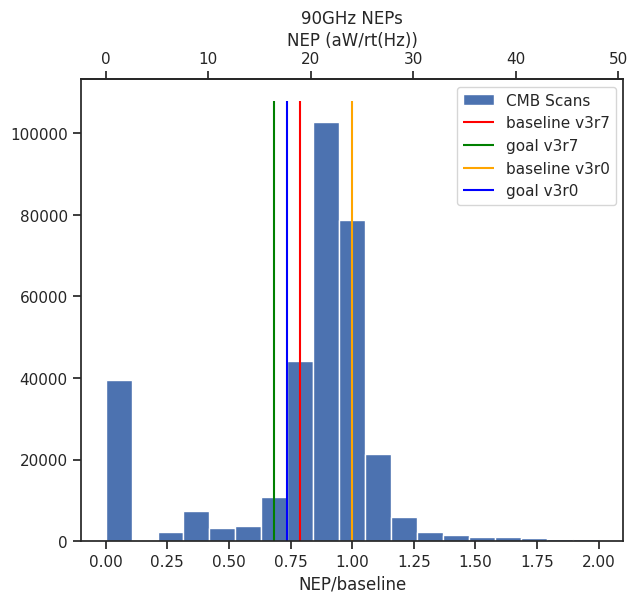

In [149]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "090") != -1)[0]

baseline_r0 = 24.04
baseline_r7 = 18.99

goal_r0 = 17.70
goal_r7 = 16.37

plt.hist(neps[flags] * 1e6 / baseline_r0, bins=np.linspace(0, 2, 20), label="CMB Scans")
# plt.hist(neps_snork_090*1e6/baseline, bins = np.linspace(0,2, 20), label = "Snorkel Stare", density = True, alpha = 0.5)
ymax, ymin = ax.get_ylim()
plt.vlines(baseline_r7 / baseline_r0, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7 / baseline_r0, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0 / baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0 / baseline_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.xlabel("NEP/baseline")
plt.title("90GHz NEPs")
plt.legend()


secax = ax.secondary_xaxis("top", functions=(denorm, normalize))
secax.set_xlabel("NEP (aW/rt(Hz))")

f.savefig("./plts/nets/neps_090.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neps_090.png", dpi=600, bbox_inches="tight")

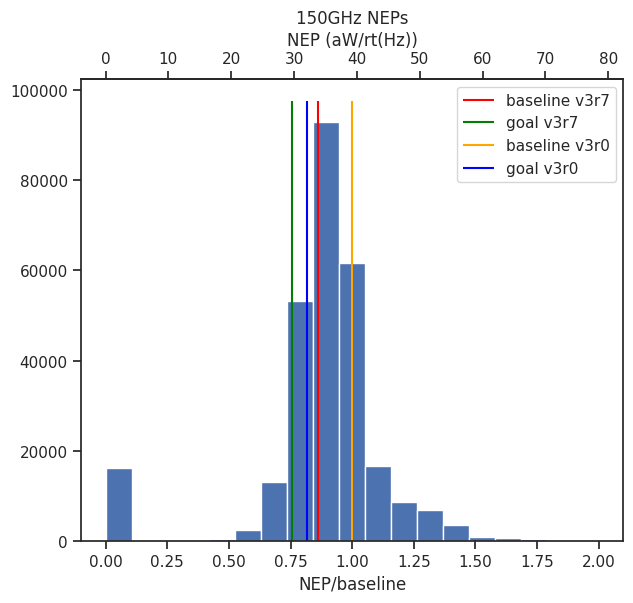

In [144]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "150") != -1)[0]

baseline_r0 = 39.25
baseline_r7 = 33.81

goal_r0 = 32.13
goal_r7 = 29.72

plt.hist(neps[flags] * 1e6 / baseline_r0, bins=np.linspace(0, 2, 20))
ymax, ymin = ax.get_ylim()
plt.vlines(baseline_r7 / baseline_r0, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7 / baseline_r0, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0 / baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0 / baseline_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.xlabel("NEP/baseline")
plt.title("150GHz NEPs")
plt.legend()

secax = ax.secondary_xaxis("top", functions=(denorm, normalize))
secax.set_xlabel("NEP (aW/rt(Hz))")

f.savefig("./plts/nets/neps_150.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neps_150.png", dpi=600, bbox_inches="tight")

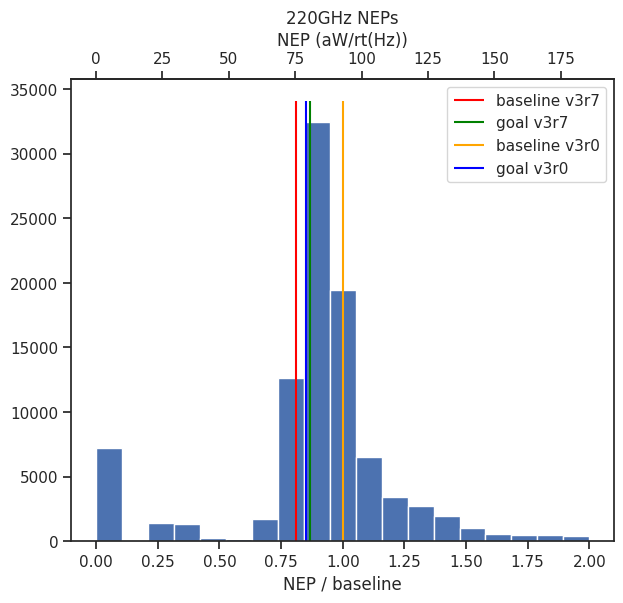

In [145]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "220") != -1)[0]

baseline_r0 = 92.86
baseline_r7 = 75.43

goal_r0 = 78.89
goal_r7 = 80.56

plt.hist(neps[flags] * 1e6 / baseline_r0, bins=np.linspace(0, 2, 20))
ymax, ymin = ax.get_ylim()
plt.vlines(baseline_r7 / baseline_r0, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7 / baseline_r0, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0 / baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0 / baseline_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.xlabel("NEP / baseline")
plt.title("220GHz NEPs")
plt.legend()

secax = ax.secondary_xaxis("top", functions=(denorm, normalize))
secax.set_xlabel("NEP (aW/rt(Hz))")

f.savefig("./plts/nets/neps_220.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neps_220.png", dpi=600, bbox_inches="tight")

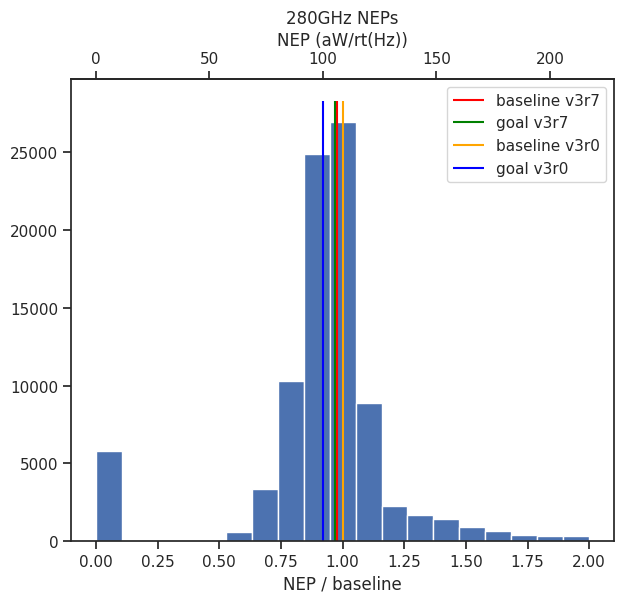

In [147]:
f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "280") != -1)[0]

baseline_r0 = 108.63
baseline_r7 = 106.37

goal_r0 = 99.79
goal_r7 = 105.25

plt.hist(neps[flags] * 1e6 / baseline_r0, bins=np.linspace(0, 2, 20))
ymax, ymin = ax.get_ylim()
plt.vlines(baseline_r7 / baseline_r0, ymin, ymax, label="baseline v3r7", color="red")
plt.vlines(goal_r7 / baseline_r0, ymin, ymax, label="goal v3r7", color="green")
plt.vlines(baseline_r0 / baseline_r0, ymin, ymax, label="baseline v3r0", color="orange")
plt.vlines(goal_r0 / baseline_r0, ymin, ymax, label="goal v3r0", color="blue")
plt.xlabel("NEP / baseline")
plt.title("280GHz NEPs")
plt.legend()

secax = ax.secondary_xaxis("top", functions=(denorm, normalize))
secax.set_xlabel("NEP (aW/rt(Hz))")

f.savefig("./plts/nets/neps_280.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neps_280.png", dpi=600, bbox_inches="tight")

### NEP vs PWV

In [172]:
sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
# f, ax = plt.subplots(figsize=(7, 6))

# Add in points to show each observation

mask = df["labels"].str.contains("090_mv14", case=False, na=False)

ymin = 0.95 * np.amin(df[mask]["neps"])
ymax = 1.05 * np.amax(df[mask]["neps"])


sns.lmplot(data=df[mask], x=df[mask].pwv / np.sin(np.deg2rad(df[mask].el)), y="neps")

plt.ylim(ymin, ymax)


# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="pwv (mm)", ylabel=r"NEP ($pW / \sqrt{Hz}$)")
sns.despine(trim=True, left=True)

plt.legend()
# f.savefig("./plts/nets/neps_mf.pdf", dpi=600, bbox_inches='tight')
# f.savefig("./plts/nets/neps_mf.png", dpi=600, bbox_inches='tight')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

# NEIs

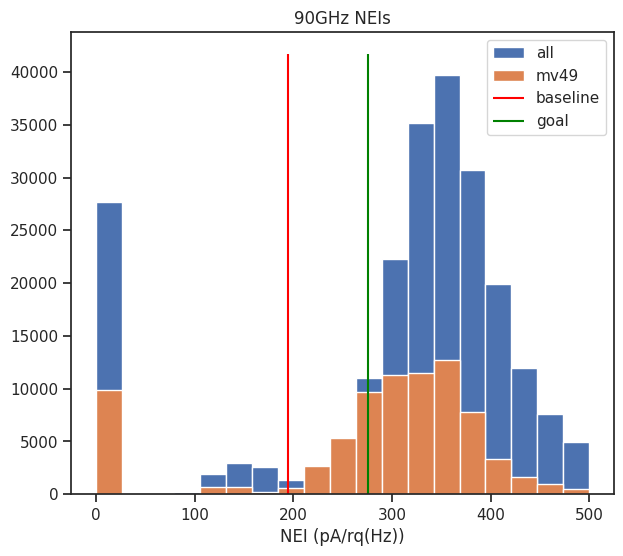

In [9]:
R_BOLO = 0.004  # From bolocalc https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_SAT_base = 3.42
P_SAT_goal = 1.94  # https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_OPT_base = 1.04  # https://github.com/simonsobs/bolocalc-so-model/blob/master/V3r7/V3r7_Baseline/LAT/MF/sensitivity.txt
P_OPT_goal = 1.06

Si_base = 1 / np.sqrt(R_BOLO * (P_SAT_base - P_OPT_base))
Si_goal = 1 / np.sqrt(R_BOLO * (P_SAT_goal - P_OPT_goal))

f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "mv49") != -1)[0]
flags_090 = np.where(np.char.find(nep_labels, "090") != -1)[0]

plt.hist(neis[flags_090], bins=np.linspace(0, 500, 20), label="all")
plt.hist(neis[flags], bins=np.linspace(0, 500, 20), label="mv49")
ymax, ymin = ax.get_ylim()
plt.vlines(18.99 * Si_base, ymin, ymax, label="baseline", color="red")
plt.vlines(16.37 * Si_goal, ymin, ymax, label="goal", color="green")
plt.xlabel("NEI (pA/rq(Hz))")
plt.title("90GHz NEIs")
plt.legend()

f.savefig("./plts/nets/neis_090.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neis_090.png", dpi=600, bbox_inches="tight")

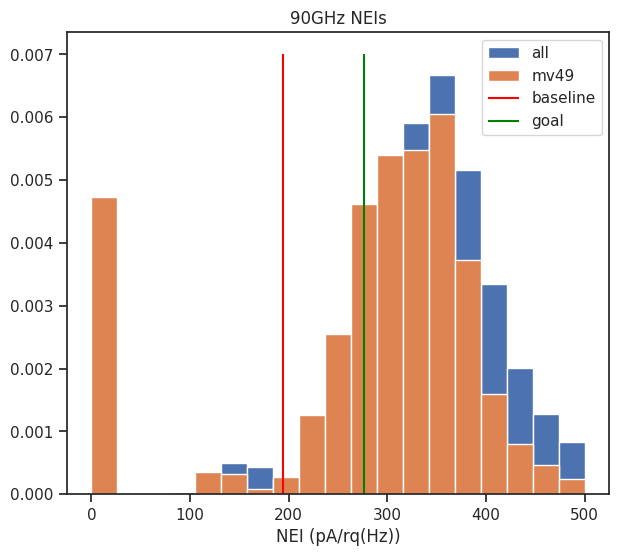

In [19]:
obs_set = np.unique(np.array(obs))


R_BOLO = 0.004  # From bolocalc https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_SAT_base = 3.42
P_SAT_goal = 1.94  # https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_OPT_base = 1.04  # https://github.com/simonsobs/bolocalc-so-model/blob/master/V3r7/V3r7_Baseline/LAT/MF/sensitivity.txt
P_OPT_goal = 1.06

Si_base = 1 / np.sqrt(R_BOLO * (P_SAT_base - P_OPT_base))
Si_goal = 1 / np.sqrt(R_BOLO * (P_SAT_goal - P_OPT_goal))

f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "mv49") != -1)[0]
flags_090 = np.where(np.char.find(nep_labels, "090") != -1)[0]
plt.hist(neis[flags_090], bins=np.linspace(0, 500, 20), label="all", density=True)
plt.hist(neis[flags], bins=np.linspace(0, 500, 20), label="mv49", density=True)


ymax, ymin = ax.get_ylim()
plt.vlines(18.99 * Si_base, ymin, ymax, label="baseline", color="red")
plt.vlines(16.37 * Si_goal, ymin, ymax, label="goal", color="green")
plt.xlabel("NEI (pA/rq(Hz))")
plt.title("90GHz NEIs")
plt.legend()

f.savefig("./plts/nets/neis_090.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neis_090.png", dpi=600, bbox_inches="tight")

In [42]:
times = np.zeros(len(obs_set))
for i in range(len(times)):
    times[i] = float(obs_set[i][4:14])

ys = np.zeros(len(times))
yerr = np.zeros(len(times))
for i in range(len(ys)):
    flags = np.where(np.char.find(obs, str(obs_set[i])) != -1)[0]
    ys[i] = np.nanmean(neis[flags])
    yerr = np.std(neis[flags])

<ErrorbarContainer object of 3 artists>

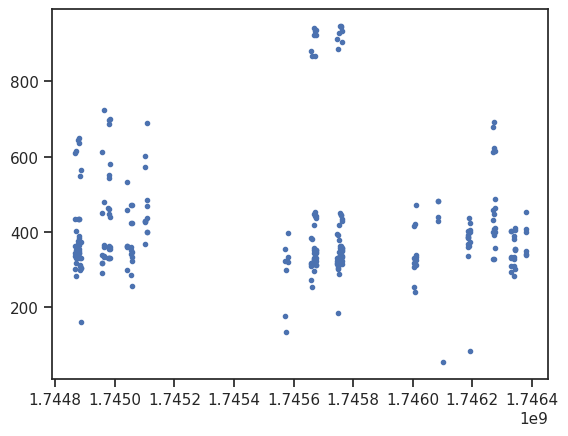

In [50]:
plt.errorbar(times, ys, yerr=np.sqrt(yerr), marker=".", ecolor="k", linestyle="")

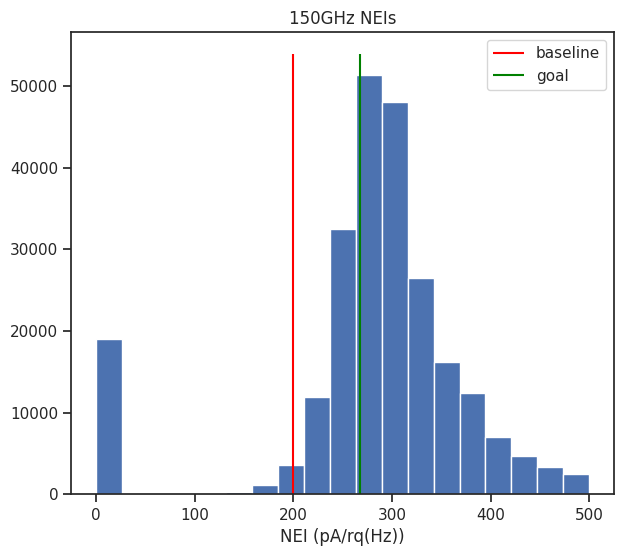

In [9]:
R_BOLO = 0.004  # From bolocalc https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_SAT_base = 9.37
P_SAT_goal = 5.33  # https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_OPT_base = 2.23  # https://github.com/simonsobs/bolocalc-so-model/blob/master/V3r7/V3r7_Baseline/LAT/MF/sensitivity.txt
P_OPT_goal = 2.25

Si_base = 1 / np.sqrt(R_BOLO * (P_SAT_base - P_OPT_base))
Si_goal = 1 / np.sqrt(R_BOLO * (P_SAT_goal - P_OPT_goal))

f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "150") != -1)[0]

plt.hist(neis[flags], bins=np.linspace(0, 500, 20))
ymax, ymin = ax.get_ylim()
plt.vlines(33.81 * Si_base, ymin, ymax, label="baseline", color="red")
plt.vlines(29.72 * Si_goal, ymin, ymax, label="goal", color="green")
plt.xlabel("NEI (pA/rq(Hz))")
plt.title("150GHz NEIs")
plt.legend()

f.savefig("./plts/nets/neis_150.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neis_150.png", dpi=600, bbox_inches="tight")

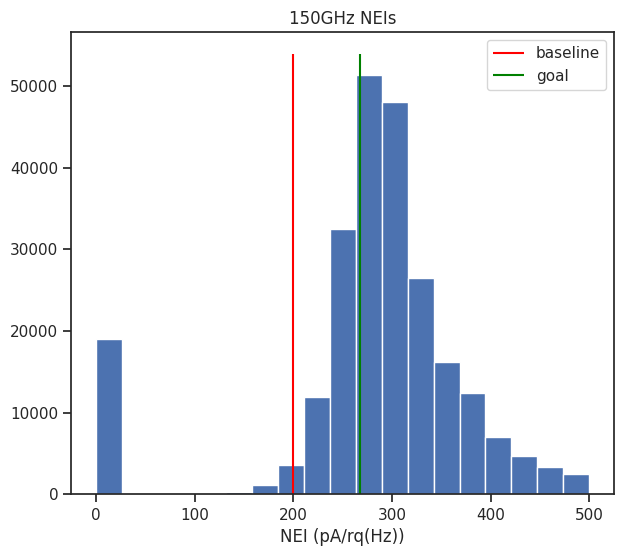

In [10]:
R_BOLO = 0.004  # From bolocalc https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_SAT_base = 9.37
P_SAT_goal = 5.33  # https://github.com/simonsobs/bolocalc-so-model/blob/848ba3b6f611788b11b782a0a816a802c21fadbe/V3r7/V3r7_Goal/LAT/MF/config/channels.txt
P_OPT_base = 2.23  # https://github.com/simonsobs/bolocalc-so-model/blob/master/V3r7/V3r7_Baseline/LAT/MF/sensitivity.txt
P_OPT_goal = 2.25

Si_base = 1 / np.sqrt(R_BOLO * (P_SAT_base - P_OPT_base))
Si_goal = 1 / np.sqrt(R_BOLO * (P_SAT_goal - P_OPT_goal))

f, ax = plt.subplots(figsize=(7, 6))
flags = np.where(np.char.find(nep_labels, "150") != -1)[0]

plt.hist(neis[flags], bins=np.linspace(0, 500, 20))
ymax, ymin = ax.get_ylim()
plt.vlines(33.81 * Si_base, ymin, ymax, label="baseline", color="red")
plt.vlines(29.72 * Si_goal, ymin, ymax, label="goal", color="green")
plt.xlabel("NEI (pA/rq(Hz))")
plt.title("150GHz NEIs")
plt.legend()

f.savefig("./plts/nets/neis_150.pdf", dpi=600, bbox_inches="tight")
f.savefig("./plts/nets/neis_150.png", dpi=600, bbox_inches="tight")